# The Vanilla Pipeline — Our Baseline

## What problem does this solve?

Most retrieval-augmented generation tutorials open with three sentences of motivation and then drop you into a 200-line framework call. By the time the model answers, you have no mental model for what each step did, why it exists, or where the failure modes live. This notebook is the opposite. We build the simplest end-to-end RAG pipeline that could possibly work, with one logical step per cell, and we treat the rest of the cookbook as a series of measured improvements over it.
There is a deeper reason to start here. Every later recipe — Self-RAG, CRAG, GraphRAG, ColPali — claims to beat "the baseline". If we never write the baseline down precisely, we have no way to verify those claims. The vanilla pipeline you build here is what `cookbook.baselines.vanilla_pipeline` exposes to every other notebook for direct side-by-side comparison.

## Where it came from

The shape — chunk, embed, store, top-k retrieve, stuff into prompt, generate — was nailed down by the original 2020 RAG paper from Lewis et al. and popularized by the LangChain and LlamaIndex tutorials in late 2022 and early 2023. None of the pieces are new. What changed in 2024 and 2025 is that we now know exactly *which* pieces leak the most quality and how to tune each one. Knowing the baseline cold is the prerequisite for any of that.

## Where it fits in the RAG landscape

Think of the cookbook as a tree rooted at this notebook. The three big branches you will encounter:

1. **Better chunks** (Recipes 5–12) — replace fixed-window chunks with semantic boundaries, late chunking, propositions, parent-child, RAPTOR trees, doc-summary routing, or matryoshka coarse-to-fine.
2. **Better retrieval** (Recipes 13–23) — rewrite the query, fan out paraphrases, switch to hybrid dense + BM25, add late interaction, then rerank.
3. **Better orchestration** (Recipes 24–34) — let the model decide whether to retrieve at all, retry on bad scores, walk a knowledge graph, or carry memory across turns.

Every branch competes against the same root. If your fancy technique cannot beat the vanilla pipeline on your data, your technique is overhead, not improvement.

## When to use it (and when not to)

Use the vanilla pipeline as your reference implementation. In production it is also a perfectly serviceable system for narrow, well-scoped corpora — a single product manual, an FAQ, a customer support knowledge base of a few thousand documents. Most production RAG that "just works" is not far from what you build here, with one or two well-chosen extras: a reranker for quality, prompt caching for cost, and a query cache for latency.
Avoid it when: your corpus mixes very different document types and a single retrieval strategy will not serve all of them (route first, recipes 11 and 17); when answers require reasoning across multiple chunks (recipes 10, 14, 16, 31–33); when documents are visual and OCR loses the layout (recipes 35–36); or when your users will ask questions whose answers are not in the corpus at all (recipes 24–26 add the machinery for that).

## The intuition

Three intuitions are worth carrying with you everywhere in this cookbook:

**Embeddings are lossy summaries.** A 1024-dim vector cannot preserve everything a 400-word chunk says. Cosine similarity finds chunks that are *topically near* the question, which is correlated with — but not the same as — chunks that *answer* the question. That gap is what every later technique is trying to close.

**The prompt is the API.** Whatever you stuff into the prompt is what the model sees. If retrieval returns noisy chunks, the model will hallucinate confidently from them. The model is not a guardrail; the prompt is.

**Latency lives in the LLM call.** Embedding, indexing, and vector search are all sub-50 ms operations on commodity hardware. The generation call is the second-and-a-half elephant in your latency budget. Every recipe that adds *more* LLM calls (reranking, reflection, multi-step) is buying quality with wall time.

## Architecture

```mermaid
flowchart LR
  D[Documents] --> C[Fixed-window<br/>chunker]
  C --> E[Embedder<br/>Nebius]
  E --> S[(Qdrant<br/>in-memory)]
  Q[User Question] --> QE[Embed query]
  QE --> R[Top-k cosine search]
  S --> R
  R --> P[Stuff into prompt]
  P --> L[LLM]
  L --> A[Answer]
  style D fill:#e9efff
  style A fill:#e9ffe9
```

## References

- 📄 [Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks (Lewis et al., 2020)](https://arxiv.org/abs/2005.11401) — The paper that named RAG
- 📚 [LlamaIndex: A High-Level Concepts overview](https://developers.llamaindex.ai/python/framework/getting_started/concepts) — Canonical naming for chunks/nodes/retrievers
- 📚 [Qdrant Vector Search Documentation](https://qdrant.tech/documentation/) — The vector store we use for the baseline
- 📚 [LiteLLM — One SDK for 100+ LLMs](https://docs.litellm.ai/) — The thin client behind cookbook.providers
- 📝 [Anthropic Contextual Retrieval (2024)](https://www.anthropic.com/news/contextual-retrieval) — Where to go next — Recipe 7 in this cookbook
- 📚 [Nebius AI Studio quickstart](https://studio.nebius.com/docs/) — OpenAI-compatible endpoint we default to

## Setup

Pick a provider via the `PROVIDER` env var; everything below is provider-agnostic. The default is Nebius. Tracing is off by default in published notebooks so the outputs are clean — flip `COOKBOOK_TRACING=phoenix` to send spans to a local Phoenix UI.

In [1]:
import os
os.environ.setdefault('PROVIDER', 'nebius')
os.environ.setdefault('COOKBOOK_TRACING', 'off')

from cookbook.providers import LLMClient
from cookbook.tracing import init_tracing

client = LLMClient()
print(f'Provider: {client.provider}  |  Chat model: {client.chat_model}')
print(init_tracing())

Provider: nebius  |  Chat model: meta-llama/Llama-3.3-70B-Instruct
Tracing disabled.


## Build the Pipeline, Step by Step

### Step 1 — Load the corpus

We are going to retrieve over the markdown chapters of *The Rust Programming Language* (CC BY 4.0). Eighteen chapters, well-written prose, dense technical content with code blocks. A representative test for any RAG system aimed at technical documentation. The loader yields plain `Document` records with stable IDs and metadata.

In [2]:
from cookbook.corpora import load_rust_book

docs = list(load_rust_book())
print(f'Loaded {len(docs)} chapters.')
print()
print('First chapter preview:')
first = docs[0]
print(f'  doc_id   : {first.doc_id}')
print(f'  source   : {first.source}')
print(f'  metadata : {first.metadata}')
print(f'  text     : {first.text[:240]}...')

Loaded 18 chapters.

First chapter preview:
  doc_id   : rust-book:ch01-00-getting-started
  source   : cc-by:rust-book
  metadata : {'chapter': 'ch01-00-getting-started', 'title': 'Getting Started'}
  text     : # Getting Started

Let’s start your Rust journey! There’s a lot to learn, but every journey starts
somewhere. In this chapter, we’ll discuss:

- Installing Rust on Linux, macOS, and Windows
- Writing a program that prints `Hello, world!`
- ...


Notice the IDs are URLs we can cite, and the metadata carries chapter information we could later use as a retrieval filter (Recipe 20). The text is the raw markdown straight from the book repository — fences, headings, prose. We deliberately do not strip the markdown; the model handles it fine and the structure helps retrieval.

### Step 2 — Chunk the corpus

We slice each chapter into overlapping windows of about 384 tokens with 64-token overlap. This is the un-tuned default — Recipe 4 sweeps the window size to show how much it matters; Recipe 5 swaps fixed-window for semantic-boundary cuts. Today, we want the simplest possible chunker so the rest of the pipeline is the only thing changing.

In [3]:
from cookbook.chunkers import fixed_window

chunks = fixed_window(docs, target_tokens=384, overlap_tokens=64)
print(f'Built {len(chunks)} chunks from {len(docs)} chapters.')
print(f'Avg chunk length (tokens, approx): {sum(len(c.text.split()) for c in chunks) // len(chunks)}')
print()
print('First chunk:')
print(f'  chunk_id : {chunks[0].chunk_id}')
print(f'  doc_id   : {chunks[0].doc_id}')
print(f'  text     : {chunks[0].text[:240]!r}')

Built 48 chunks from 18 chapters.
Avg chunk length (tokens, approx): 291

First chunk:
  chunk_id : rust-book:ch01-00-getting-started#fw0000
  doc_id   : rust-book:ch01-00-getting-started
  text     : '# Getting Started Let’s start your Rust journey! There’s a lot to learn, but every journey starts somewhere. In this chapter, we’ll discuss: - Installing Rust on Linux, macOS, and Windows - Writing a program that prints `Hello, world!` - Us'


Each `Chunk` carries its parent `doc_id`, so even after retrieval the result remembers which chapter it came from. That parent link is what Recipes 9 (parent-child) and 11 (document-summary routing) build on.

### Step 3 — Embed the chunks

Now we hand the chunk texts to Nebius's embedding model and get one vector per chunk. The cookbook's `client.embed()` call is cached on disk by SHA256 of `(provider, model, text)`, so the second time we run this notebook the embedding pass is free. First-time cost on the Rust corpus is small — under a few cents at current Nebius pricing.

In [4]:
vectors = client.embed([c.text for c in chunks])
print(f'Got {len(vectors)} vectors, dim={len(vectors[0])}')

import numpy as np
v = np.asarray(vectors[0])
print(f'First vector norm: {np.linalg.norm(v):.3f}')
print(f'First 8 dims:     {[round(x, 3) for x in v[:8]]}')

Got 48 vectors, dim=4096


First vector norm: 1.000
First 8 dims:     [np.float64(0.007), np.float64(-0.002), np.float64(0.001), np.float64(-0.018), np.float64(0.003), np.float64(-0.033), np.float64(-0.003), np.float64(0.028)]


Embedding norm being close to 1 tells you the model returns L2-normalized vectors, so cosine similarity reduces to a dot product. Norms far from 1 sometimes hint at an embedding-API misconfiguration (wrong model, dimension mismatch).

### Step 4 — Index in Qdrant

Qdrant stores the vectors and lets us search them. We use the in-memory mode here so the notebook is reproducible without a running server. In production you would point at a Qdrant cluster URL (`QDRANT_URL`) and add a payload schema; the search code stays identical.

In [5]:
from cookbook.stores import QdrantBackend

store = QdrantBackend('vanilla-rust', dim=len(vectors[0]))
store.add(
    texts=[c.text for c in chunks],
    vectors=vectors,
    metadatas=[c.metadata for c in chunks],
    ids=[c.chunk_id for c in chunks],
)
print(f'Indexed {len(chunks)} chunks into Qdrant collection "vanilla-rust".')

C:\Users\faree\Desktop\rag\rag-cookbook-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Indexed 48 chunks into Qdrant collection "vanilla-rust".


Indexing is essentially free at this scale. The interesting case is when you have millions of vectors — there Qdrant's HNSW parameters and quantization start mattering. Recipe 12 (Matryoshka) is one path to making large-scale search cheap.

### Step 5 — Define a retrieval function

Embed the question, ask Qdrant for the top-k closest chunks. That is it. Notice we return both the texts and their similarity scores — we will look at the scores in the inspection section.

In [6]:
from cookbook.stores import Hit

def retrieve(question: str, k: int = 5) -> list[Hit]:
    q_vec = client.embed([question])[0]
    return store.search(q_vec, top_k=k)

### Step 6 — Stuff retrieved chunks into a prompt

The simplest possible prompt: concatenate the chunks, paste the question, ask for an answer. Every later recipe varies *what* gets stuffed and *how* it gets framed, but the bones are this. We name the function `answer_question` because the rest of the cookbook expects that name when comparing to a baseline.

In [7]:
PROMPT = (
    'Answer the question using only the passages below. '
    'If the passages do not contain the answer, say so plainly.\n\n'
    'Passages:\n{context}\n\nQuestion: {question}\nAnswer:'
)

def answer_question(question: str, k: int = 5) -> tuple[str, list[str]]:
    hits = retrieve(question, k=k)
    contexts = [h.text for h in hits]
    answer = client.chat(PROMPT.format(
        context='\n\n'.join(contexts),
        question=question,
    ))
    return answer, contexts

`answer_question` returns `(answer, contexts)` because every later recipe is going to compare both — not just the answer string, but *what was retrieved* that led to it. RAGAS context-precision and context-recall live in those `contexts`.

## Look Inside

### Inspect — what does a single retrieval look like?

Before we fire a real question, we should know what Qdrant returns. We will use a deliberately specific query so the top hits are obviously on-topic, then look at scores, IDs, and snippets.

In [8]:
question = 'How does the borrow checker enforce that mutable references are exclusive?'
hits = retrieve(question, k=5)
for i, h in enumerate(hits, 1):
    print(f'{i}. score={h.score:.3f}  id={h.doc_id}')
    print(f'   {h.text[:180]}...')
    print()

1. score=0.660  id=rust-book:ch15-00-smart-pointers#fw0001
   a general design pattern used frequently in Rust, this chapter won’t cover every existing smart pointer. Many libraries have their own smart pointers, and you can even write your o...

2. score=0.642  id=rust-book:ch15-00-smart-pointers#fw0000
   # Smart Pointers A pointer is a general concept for a variable that contains an address in memory. This address refers to, or “points at,” some other data. The most common kind of ...

3. score=0.622  id=rust-book:ch04-00-understanding-ownership#fw0000
   # Understanding Ownership Ownership is Rust’s most unique feature and has deep implications for the rest of the language. It enables Rust to make memory safety guarantees without n...

4. score=0.555  id=rust-book:ch10-00-generics#fw0000
   # Generic Types, Traits, and Lifetimes Every programming language has tools for effectively handling the duplication of concepts. In Rust, one such tool is _generics_: abstract sta...

5. score=

A few things to read for:

- The top score should be visibly higher than the bottom score. If it is not, retrieval is shaky — usually a sign of either a too-small chunk or a query that lives in the wrong embedding subspace (Recipe 13 fixes the latter).
- The top hit's text should obviously contain the word "borrow" or its synonyms. Recall failures often have a top hit that is *adjacent* but not on-target.
- The IDs let you trace exactly which chapter answered. In production that mapping is what powers citations.

### Inspect — how good is the score signal?

A scatter of the top-20 hits' scores tells you how *peaked* retrieval is. A steep curve means the top result is much better than the rest; a flat curve means retrieval is uncertain and the model will be working from noisy context.

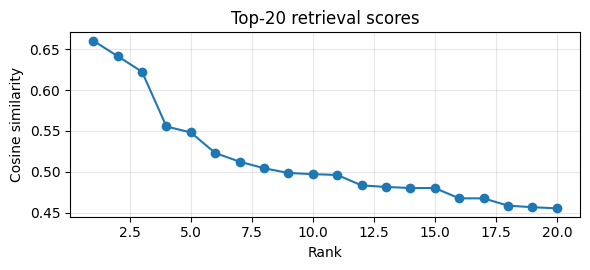

In [9]:
import matplotlib.pyplot as plt

scores = [h.score for h in retrieve(question, k=20)]
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.plot(range(1, len(scores) + 1), scores, marker='o')
ax.set_xlabel('Rank')
ax.set_ylabel('Cosine similarity')
ax.set_title('Top-20 retrieval scores')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

On the Rust book, this curve usually drops sharply between ranks 1-3 and then plateaus around 0.5-0.6. The plateau is the long tail of *somewhat related* chunks. The reranker in Recipe 22 is the tool of choice when the top-3 is right but rank-5 is junk — it lets you keep `k=5` for context width without polluting the prompt.

### Inspect — what does the assembled prompt actually look like?

The prompt is what the model sees. Print it.

In [10]:
hits = retrieve(question, k=3)
rendered = PROMPT.format(
    context='\n\n'.join(h.text for h in hits),
    question=question,
)
print(f'Prompt length: {len(rendered)} chars')
print('--- first 1000 chars ---')
print(rendered[:1000])
print('...')

Prompt length: 3670 chars
--- first 1000 chars ---
Answer the question using only the passages below. If the passages do not contain the answer, say so plainly.

Passages:
a general design pattern used frequently in Rust, this chapter won’t cover every existing smart pointer. Many libraries have their own smart pointers, and you can even write your own. We’ll cover the most common smart pointers in the standard library: - `Box<T>`, for allocating values on the heap - `Rc<T>`, a reference counting type that enables multiple ownership - `Ref<T>` and `RefMut<T>`, accessed through `RefCell<T>`, a type that enforces the borrowing rules at runtime instead of compile time In addition, we’ll cover the _interior mutability_ pattern where an immutable type exposes an API for mutating an interior value. We’ll also discuss reference cycles: how they can leak memory and how to prevent them. Let’s dive in!

# Smart Pointers A pointer is a general concept for a variable that contains an address in me

When something goes wrong with a RAG system, this is usually the first thing to look at: is the prompt well-formed, is the right context present, is the question phrased clearly? Phoenix tracing (Recipe 39) gives you this view for every call automatically.

### Inspect — token budget reality check

We are stuffing five chunks (~1900 tokens) plus a system prompt into every call. With `k=20` the prompt balloons. Knowing your token footprint matters for cost and for the next set of recipes — late chunking, contextual headers, and reranking all touch this.

In [11]:
import tiktoken
enc = tiktoken.get_encoding('cl100k_base')
lengths = [len(enc.encode(h.text)) for h in retrieve(question, k=20)]
import statistics
print(f'tokens/chunk:  min={min(lengths)}  median={statistics.median(lengths):.0f}  max={max(lengths)}')
print(f'k=5 prompt budget: ~{sum(lengths[:5])} tokens of context')
print(f'k=20 prompt budget: ~{sum(lengths)} tokens of context')

tokens/chunk:  min=74  median=355  max=650
k=5 prompt budget: ~1629 tokens of context
k=20 prompt budget: ~7151 tokens of context


If your generator is a $50-per-million-input-tokens model, every k+15 extra retrieval chunks costs you about a tenth of a cent per query, all day, forever. Two-stage retrieve-then-rerank (Recipe 22) lets you keep `k=5` for the LLM while still shortlisting 50 candidates upstream.

## Run It

Now the full pipeline on a realistic question. We will print the answer and the chunks that informed it.

In [12]:
from textwrap import fill

question = 'When should I prefer Arc over Rc, and what guarantees do I lose if I switch?'
answer, contexts = answer_question(question, k=5)
print('=== Answer ===')
print(fill(answer, width=100))
print()
print('=== Contexts retrieved ===')
for i, c in enumerate(contexts, 1):
    print(f'[{i}] {c[:200]}...')
    print()

=== Answer ===
The passages do not contain the answer to this question. They discuss smart pointers, ownership,
concurrency, and functional language features, but do not mention `Arc` or compare it to `Rc`.

=== Contexts retrieved ===
[1] a general design pattern used frequently in Rust, this chapter won’t cover every existing smart pointer. Many libraries have their own smart pointers, and you can even write your own. We’ll cover the ...

[2] # Smart Pointers A pointer is a general concept for a variable that contains an address in memory. This address refers to, or “points at,” some other data. The most common kind of pointer in Rust is a...

[3] # Understanding Ownership Ownership is Rust’s most unique feature and has deep implications for the rest of the language. It enables Rust to make memory safety guarantees without needing a garbage col...

[4] # Fearless Concurrency Handling concurrent programming safely and efficiently is another of Rust’s major goals. _Concurrent programmin

## Knobs to Turn

Four levers in the order you should reach for them:

1. **Chunk size and overlap.** Defaults of 384 / 64 are reasonable for prose; Recipe 4 sweeps them and shows the optimum is often 256 or 512 depending on corpus density. Single biggest cheap win.
2. **`k` (number of retrieved chunks).** Increasing `k` improves recall but adds tokens to the prompt linearly. Most production systems land between 3 and 8.
3. **Embedding model.** Switching `client.embed_model` to a stronger family (Voyage 3, Cohere Embed 4, BGE-M3 finetuned on your domain) is the next biggest lift. Recipe 3 compares four families.
4. **Prompt wording.** "Answer using only these passages" reduces hallucination at the cost of asking the model to refuse more often. Tighten it for high-precision use cases; relax for assistant-style chat.

Things *not* to tune at this stage: similarity metric (cosine is fine), distance threshold (set `k` instead), reranker (that is Recipe 22 — do not add a reranker until you have measured that the top-`k` is the failure mode).

## Evaluate on a Slice

Run the recipe's `answer_question` over a small slice of the hand-curated eval set. Full RAGAS metrics are exercised in `recipes/09-evaluation-and-production/ragas-triad-eval.ipynb`; here we just print a quick spot-check table so you can eyeball whether the technique is on track.

In [13]:
from cookbook.corpora import load_eval_questions
from cookbook.eval import EvalSample

qs = load_eval_questions()
qs = [q for q in qs if q['corpus'] == 'rust-book']
samples = []
for row in qs[:5]:
    answer, contexts = answer_question(row['question'])
    samples.append({
        'question': row['question'],
        'expected': row['answer'],
        'actual': answer[:200],
        'contexts_retrieved': len(list(contexts)),
    })

import pandas as pd
pd.DataFrame(samples)

,question,expected,actual,contexts_retrieved
0,What is ownership in Rust?,A set of rules governing how memory is managed...,Ownership in Rust is a feature that enables Ru...,5
1,What does the borrow checker do?,It statically enforces that references obey th...,The passages do not contain the answer. They m...,5
2,What is the difference between String and &str?,"`String` is an owned, heap-allocated, growable...",The passages do not contain information about ...,5
3,Describe how match is exhaustive in Rust.,The compiler requires `match` arms to cover ev...,The passages do not contain a direct descripti...,5
4,What is a trait?,A trait is a named set of methods that types c...,The passages provided do not contain a direct ...,5


## Closing Thoughts

If you only ship this notebook, you have a perfectly usable RAG system for a narrow corpus. Most users would not notice the difference between this and a much fancier pipeline on questions whose answers are in a single chapter.

Where this falls down — and where every later recipe earns its complexity:

- **Multi-hop questions** ("How do Arc and Mutex compose, and what does that look like in code?") routinely retrieve from one chapter and miss the other. Recipes 10 (RAPTOR) and 14 (multi-query fusion) address this.
- **Questions outside the corpus** trigger confident hallucination. Recipes 24 (Self-RAG) and 25 (CRAG) wire in detection and fallback.
- **Visual content** (tables, figures, equations) is invisible to text-only retrieval. Recipes 35–36 handle this.
- **Personalization** across user sessions has no machinery here. Recipe 34 (Mem0) adds it.

Treat every other notebook as a measured patch against this baseline. The first cell of each will import `cookbook.baselines.vanilla_pipeline` and run it side by side with the new technique on the same question.